# Hackathon ONE G9 · FinanceAI — Análisis Financiero Inteligente

**Equipo 44 · LATAM** — Notebook de entrenamiento reproducible.

Este cuaderno construye y serializa los **dos modelos** del producto:

| Modelo | Entrada | Salida | Consumido por |
|---|---|---|---|
| Clasificador de gastos | descripción de la transacción | una de 8 categorías + confianza | `POST /clasificar` |
| Perfil financiero | agregados por categoría + ingreso, deuda y hábito de ahorro | `Saludable` / `En observación` / `En riesgo` + probabilidad | `POST /perfil` |

Al final los artefactos quedan serializados con `joblib`, publicados en **OCI Object Storage**
y verificados contra los tres ejemplos de uso documentados de la API.

## 1. Objetivo del proyecto

Convertir transacciones bancarias en bruto en información útil: categorizar el gasto,
diagnosticar la salud financiera del usuario y devolver recomendaciones concretas.

### Sobre los datos

El conjunto es sintético y lo genera `scripts/generador_usuarios.py`. Se optó por simulación
porque no hay un corpus público en español de extractos bancarios etiquetados por categoría,
y el reto lo permite.

Eso condiciona cómo hay que leer las métricas:

- La relación descripción → categoría es determinista: cada comercio pertenece a una sola
  categoría. Un acierto altísimo en una partición aleatoria es lo esperable y no demuestra
  que el modelo sirva con datos reales. Mide otra cosa: la robustez frente al ruido
  tipográfico que se inyecta a propósito.
- Para tener una señal más realista añadimos una segunda evaluación, la partición por
  comercio: se entrena sin ver ciertos comercios y se mide sobre ellos. Ese número aproxima
  lo que pasaría ante un comercio nuevo y es bastante más bajo. De ahí salen el umbral de
  confianza y el clasificador de respaldo.
- La etiqueta de perfil viene de una regla explícita con ruido gaussiano sobre rasgos
  latentes del usuario. El modelo no ve esos rasgos, solo los agregados que recibe la API,
  así que reconstruir la regla desde ahí tiene una dificultad razonable.

## 2. Importación de librerías

In [1]:
import json
import subprocess
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

print("python     ", sys.version.split()[0])
print("pandas     ", pd.__version__)
print("numpy      ", np.__version__)
print("scikit-learn", sklearn.__version__)

python      3.14.4
pandas      3.0.5
numpy       2.5.2
scikit-learn 1.9.0


## 3. Configuración del entorno

Las rutas se resuelven respecto a `ciencia-datos/`, así que el notebook corre igual desde
Jupyter, VS Code o `nbconvert`.

`features.py` se importa aquí y no se reimplementa nada de lo que contiene. Es la misma
función que usa `srv-python` en inferencia; si el notebook normalizara el texto de una forma
y la API de otra, el modelo vería en producción vectores distintos a los de entrenamiento y
ninguna métrica offline lo detectaría.

In [2]:
RAIZ = Path.cwd()
if not (RAIZ / "features.py").exists():
    RAIZ = RAIZ / "ciencia-datos"
RAIZ = RAIZ.resolve()

sys.path.insert(0, str(RAIZ))
sys.path.insert(0, str(RAIZ / "scripts"))

import features                      # noqa: E402
import oci_storage                   # noqa: E402
from limpieza_datos import consolidar # noqa: E402

DATOS_CRUDOS = RAIZ / "datos" / "crudos"
DATOS_LIMPIOS = RAIZ / "datos" / "limpios"
ARTEFACTOS = RAIZ / "artefactos"
ARTEFACTOS.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
np.random.seed(SEMILLA)

VERSION_MODELO = "1.0.0"

print("raiz       ", RAIZ)
print("categorias ", features.CATEGORIAS)
print("perfiles   ", features.PERFILES)

raiz        C:\Users\Rayle\Desktop\G9-LATAM-TEAM-44-FinanceAI-main\ciencia-datos
categorias  ('alimentacion', 'transporte', 'salud', 'vivienda', 'educacion', 'ocio', 'servicios', 'otras')
perfiles    ('Saludable', 'En observación', 'En riesgo')


## 4. Carga del conjunto de datos

Si el dataset no existe, se genera. Con la semilla fija el resultado es idéntico en
cualquier máquina, que es lo que hace reproducible al notebook.

In [3]:
if not (DATOS_CRUDOS / "usuarios.csv").exists():
    print("No hay dataset: generando 400 usuarios x 6 meses...")
    subprocess.run(
        [sys.executable, str(RAIZ / "scripts" / "generador_usuarios.py"),
         "--usuarios", "400", "--meses", "6", "--semilla", str(SEMILLA)],
        check=True,
    )

archivos = sorted(p.name for p in DATOS_CRUDOS.iterdir() if p.name.startswith("usuario_"))
print(f"{len(archivos)} extractos en bruto")
print("formatos:", pd.Series([a.split('.')[-1] for a in archivos]).value_counts().to_dict())

400 extractos en bruto
formatos: {'json': 163, 'csv': 122, 'xlsx': 115}


### 4.1 Cómo llega el dato en bruto

El generador imita un extracto real: tres formatos de archivo mezclados, tres formatos de
fecha, descripciones con prefijos de terminal (`TRF/POS`), referencias numéricas, errores
tipográficos, nulos y algún importe con el signo invertido.

In [4]:
import limpieza_datos

ejemplo = DATOS_CRUDOS / archivos[0]
crudo = limpieza_datos.leer_extracto(str(ejemplo))
print("archivo:", ejemplo.name, "| filas:", len(crudo))
crudo.head(12)

archivo: usuario_001_S.xlsx | filas: 166


,fecha,tipo,descripcion,monto,categoria,comercio
0,2026-01-01,ingresos,PAGO HONORARIOS FREELAN,4908.68,NaN,PAGO HONORARIOS FREELANCE
1,2026-01-08,egresos,Arriendo Apartamento,347.06,vivienda,Arriendo Apartamento
2,2026-01-01,egresos,CUOTA HIPOTECA VIVIENDA,762.75,vivienda,Cuota Hipoteca Vivienda
3,2026-01-15,egresos,TRF/POS Moovistar Internet Hogar,62.72,servicios,Movistar Internet Hogar
4,2026/01/11,egresos,** Gimnasio SmartFit,93.20,ocio,Gimnasio SmartFit
5,2026-01-07,egresos,DISNEY PLUS SUSCRIPCION,47.23,ocio,Disney Plus Suscripcion
6,2026-01-04,egresos,EPS Cuota Moderadora REF663054,26.98,salud,EPS Cuota Moderadora
7,2026-01-24,egresos,cabify viaje,42.92,transporte,Cabify Viaje
8,2026-01-01,egresos,PSICOLOGIA CONSULTA,78.00,salud,Psicologia Consulta
9,2026-01-25,egresos,Estacion Terpel,63.01,transporte,Estacion Terpel


In [5]:
# Radiografía de la suciedad, en números.
todos_crudos = pd.concat(
    [limpieza_datos.leer_extracto(str(DATOS_CRUDOS / a)) for a in archivos],
    ignore_index=True,
)

diagnostico = pd.Series({
    "transacciones": len(todos_crudos),
    "descripciones nulas": todos_crudos["descripcion"].isna().sum(),
    "fechas nulas": todos_crudos["fecha"].isna().sum(),
    "montos negativos": (pd.to_numeric(todos_crudos["monto"], errors="coerce") < 0).sum(),
    "sin categoria (ingresos/deudas)": todos_crudos["categoria"].isna().sum(),
})
print(diagnostico.to_string())
print()
print("Formatos de fecha presentes:")
print(todos_crudos["fecha"].dropna().astype(str).str.replace(r"\d", "9", regex=True).value_counts().head())

transacciones                      65123
descripciones nulas                 1929
fechas nulas                        2604
montos negativos                     939
sin categoria (ingresos/deudas)     4424

Formatos de fecha presentes:
fecha
9999-99-99    50113
99/99/9999     9776
9999/99/99     2630
Name: count, dtype: int64


## 5. Exploración de datos (EDA)

In [6]:
transacciones, usuarios = consolidar(str(DATOS_CRUDOS))
transacciones["usuario_id"] = transacciones["usuario_id"].astype(str).str.zfill(3)
usuarios["usuario_id"] = usuarios["usuario_id"].astype(str).str.zfill(3)

DATOS_LIMPIOS.mkdir(parents=True, exist_ok=True)
transacciones.to_csv(DATOS_LIMPIOS / "transacciones.csv", index=False, encoding="utf-8")
usuarios.to_csv(DATOS_LIMPIOS / "usuarios.csv", index=False, encoding="utf-8")

print(f"{len(transacciones):,} transacciones de {usuarios['usuario_id'].nunique()} usuarios")
transacciones.info()

65,123 transacciones de 400 usuarios
<class 'pandas.DataFrame'>
RangeIndex: 65123 entries, 0 to 65122
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   usuario_id          65123 non-null  str           
 1   fecha               65123 non-null  datetime64[ns]
 2   tipo                65123 non-null  string        
 3   descripcion         63194 non-null  string        
 4   monto               65123 non-null  float64       
 5   categoria           60699 non-null  str           
 6   comercio            65123 non-null  str           
 7   descripcion_limpia  65123 non-null  str           
dtypes: datetime64[ns](1), float64(1), str(4), string(2)
memory usage: 4.0 MB


In [7]:
print("Movimientos por tipo:")
print(transacciones["tipo"].value_counts().to_string())
print()
print("Perfiles (etiqueta a nivel usuario):")
print(usuarios["perfil"].value_counts().to_string())
print()
print("Ingreso mensual:")
print(usuarios["ingreso_mensual"].describe().round(2).to_string())

Movimientos por tipo:
tipo
egresos     60699
ingresos     3552
deudas        872

Perfiles (etiqueta a nivel usuario):
perfil
En riesgo         191
En observación    122
Saludable          87

Ingreso mensual:
count     400.00
mean     4074.65
std      1609.50
min      1222.89
25%      2644.77
50%      4113.04
75%      5394.52
max      6995.83


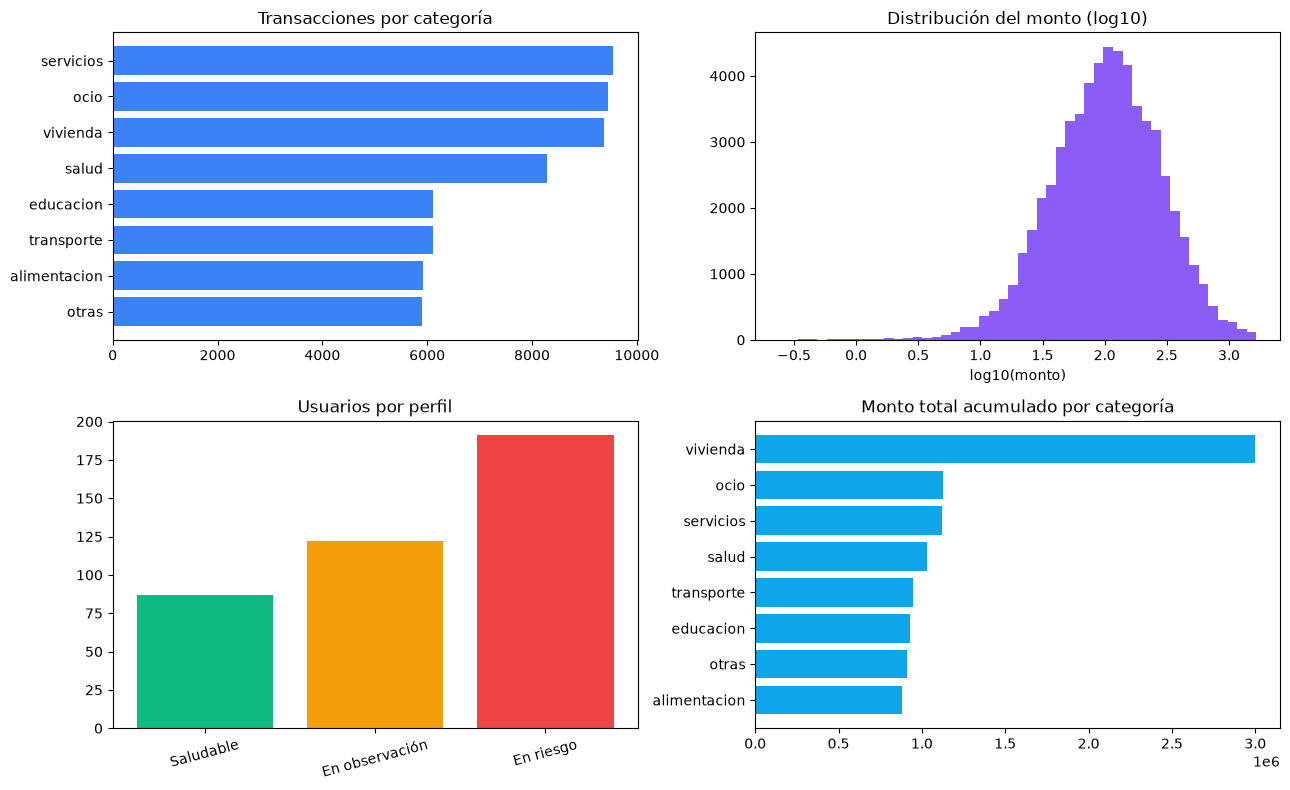

In [8]:
egresos = transacciones[transacciones["tipo"] == "egresos"].copy()

fig, ejes = plt.subplots(2, 2, figsize=(13, 8))

conteo = egresos["categoria"].value_counts()
ejes[0, 0].barh(conteo.index[::-1], conteo.values[::-1], color="#3b82f6")
ejes[0, 0].set_title("Transacciones por categoría")

ejes[0, 1].hist(np.log10(egresos.loc[egresos["monto"] > 0, "monto"]), bins=50, color="#8b5cf6")
ejes[0, 1].set_title("Distribución del monto (log10)")
ejes[0, 1].set_xlabel("log10(monto)")

orden = list(features.PERFILES)
conteo_perfil = usuarios["perfil"].map(features.normalizar_perfil).value_counts().reindex(orden)
ejes[1, 0].bar(orden, conteo_perfil.values, color=["#10b981", "#f59e0b", "#ef4444"])
ejes[1, 0].set_title("Usuarios por perfil")
ejes[1, 0].tick_params(axis="x", rotation=15)

gasto_cat = egresos.groupby("categoria")["monto"].sum().sort_values()
ejes[1, 1].barh(gasto_cat.index, gasto_cat.values, color="#0ea5e9")
ejes[1, 1].set_title("Monto total acumulado por categoría")

plt.tight_layout()
plt.show()

El número de transacciones por categoría y el monto acumulado no siguen el mismo orden.
`vivienda` tiene pocos movimientos pero pesa mucho en dinero, y `alimentacion` al revés. Por
eso el resumen de gastos de la API agrega por monto y no por conteo.

## 6. Limpieza de datos

La limpieza está en `scripts/limpieza_datos.py` para que la API y el notebook compartan
criterio. Aquí se ve el efecto sobre casos concretos.

**Fechas.** Se prueban los formatos uno a uno en lugar de usar
`pd.to_datetime(format="mixed", dayfirst=True)`. Ese atajo interpreta `2026/03/05` como el 3
de mayo y parte los agregados mensuales entre meses que no existen; el síntoma fue que
aparecían 12 meses en un dataset de 6.

**Montos.** Se toma el valor absoluto. El sentido del movimiento ya lo da la columna `tipo`,
y un negativo colándose en la suma restaría de su propia categoría.

In [9]:
# Antes y después sobre las descripciones más sucias.
sucias = transacciones[transacciones["descripcion"].astype(str).str.contains(
    r"TRF|ERR|#|\*|///|REF", regex=True, na=False)].head(8)
sucias[["descripcion", "descripcion_limpia", "categoria"]]

,descripcion,descripcion_limpia,categoria
0,TRF/POS ** Disney Plus Suscripcion REF486649,disney plus suscripcion <num>,ocio
1,ERR: Xbox Game Pass REF801765,err xbox game pass <num>,ocio
4,TRF/POS EPSCuota Moderadora,epscuota moderadora,salud
9,EPS Cuota Moderadora REF663054,eps cuota moderadora <num>,salud
16,ERR: HBO Max Mensual,err hbo max mensual,ocio
17,** Gimnasio SmartFit,gimnasio smartfit,ocio
18,TRF/POS Burger King,burger king,alimentacion
19,TRF/POS Moovistar Internet Hogar,moovistar internet hogar,servicios


In [10]:
resumen_limpieza = pd.DataFrame({
    "antes": [
        todos_crudos["descripcion"].isna().sum(),
        todos_crudos["fecha"].isna().sum(),
        (pd.to_numeric(todos_crudos["monto"], errors="coerce") < 0).sum(),
    ],
    "despues": [
        (transacciones["descripcion_limpia"] == "").sum(),
        (transacciones["fecha"] == limpieza_datos.FECHA_CENTINELA).sum(),
        (transacciones["monto"] < 0).sum(),
    ],
}, index=["descripciones sin contenido", "fechas irrecuperables", "montos negativos"])

print(resumen_limpieza.to_string())
print()
meses = transacciones.loc[transacciones["fecha"] > "1901-01-01", "fecha"].dt.to_period("M")
print("Meses calendario tras el parseo:", sorted(meses.astype(str).unique()))

                             antes  despues
descripciones sin contenido   1929     1929
fechas irrecuperables         2604     2604
montos negativos               939        0

Meses calendario tras el parseo: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']


Las fechas irrecuperables (~4%) se marcan con el centinela `1900-01-01` en vez de dejarlas
como `NaT`. Un centinela se ve en el EDA; un `NaT` desaparece en la primera agregación. Estas
filas quedan fuera del panel mensual y su volumen se reporta.

## 7. Ingeniería de características

Dos representaciones distintas, una por modelo.

### 7.1 Texto → clasificador de gastos

`features.normalizar_texto` pasa a minúsculas, quita tildes, elimina los prefijos de extracto
y colapsa las referencias numéricas largas a un token `<num>`. Sin ese colapso cada número de
referencia sería un término propio del vocabulario TF-IDF, con la mitad de ellos apareciendo
una sola vez.

In [11]:
muestras = ["TRF/POS Supermercado Exito REF483920 BOGOTA",
            "### farmacia san pablo",
            "NETFLIX STREAMING",
            "Gasolinera Pemx CDMX"]
for m in muestras:
    print(f"{m:45s} -> {features.normalizar_texto(m)}")

TRF/POS Supermercado Exito REF483920 BOGOTA   -> supermercado exito <num> bogota
### farmacia san pablo                        -> farmacia san pablo
NETFLIX STREAMING                             -> netflix streaming
Gasolinera Pemx CDMX                          -> gasolinera pemx cdmx


### 7.2 Agregados → modelo de perfil

La unidad de análisis es el usuario-mes, no el usuario. La API recibe un lote de
transacciones de un periodo junto al ingreso mensual, así que el modelo se entrena sobre esa
misma forma de dato. De paso multiplica por seis las muestras.

El vector lo construye `features.construir_features_perfil`, que solo admite los cuatro datos
que trae la petición.

In [12]:
panel = transacciones[
    (transacciones["tipo"] == "egresos") & (transacciones["fecha"] > "1901-01-01")
].copy()
panel["categoria"] = panel["categoria"].fillna("otras")
panel["mes"] = panel["fecha"].dt.to_period("M").astype(str)

pivote = panel.pivot_table(
    index=["usuario_id", "mes"], columns="categoria", values="monto", aggfunc="sum"
).fillna(0.0)
for c in features.CATEGORIAS:
    if c not in pivote.columns:
        pivote[c] = 0.0
pivote = pivote[list(features.CATEGORIAS)].reset_index()

panel_mensual = pivote.merge(usuarios, on="usuario_id", how="left")
print(f"{len(panel_mensual)} filas usuario-mes ({panel_mensual['usuario_id'].nunique()} usuarios x "
      f"{panel_mensual['mes'].nunique()} meses)")
panel_mensual.head(3)

2400 filas usuario-mes (400 usuarios x 6 meses)


,usuario_id,mes,alimentacion,transporte,salud,vivienda,educacion,ocio,servicios,otras,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,factor_gasto_latente,score_riesgo_latente,perfil,archivo,n_transacciones
0,001,2026-01,161.92,105.93,139.35,1266.50,56.98,469.20,134.65,0.00,4908.68,19.8,Baja,0.475,0.2149,Saludable,usuario_001_S.xlsx,166
1,001,2026-02,78.82,227.84,149.20,1135.29,155.85,212.69,262.32,208.46,4908.68,19.8,Baja,0.475,0.2149,Saludable,usuario_001_S.xlsx,166
2,001,2026-03,86.25,122.01,79.15,1469.97,174.03,149.36,200.57,28.87,4908.68,19.8,Baja,0.475,0.2149,Saludable,usuario_001_S.xlsx,166


In [13]:
X_perfil = pd.DataFrame([
    features.construir_features_perfil(
        fila["ingreso_mensual"], fila["nivel_endeudamiento"], fila["frecuencia_ahorro"],
        {c: fila[c] for c in features.CATEGORIAS},
    )
    for _, fila in panel_mensual.iterrows()
])[list(features.COLUMNAS_PERFIL)]

y_perfil = panel_mensual["perfil"].map(features.normalizar_perfil)
grupos = panel_mensual["usuario_id"]

print("matriz de atributos:", X_perfil.shape)
X_perfil.describe().T[["mean", "std", "min", "max"]].round(3)

matriz de atributos: (2400, 20)


,mean,std,min,max
ingreso_mensual,4074.652,1607.821,1222.890,6995.830
ratio_endeudamiento,0.435,0.181,0.000,0.850
ahorro_ordinal,0.990,0.900,0.000,3.000
gasto_total,3977.094,2084.000,322.690,12528.190
tasa_gasto,0.972,0.304,0.228,1.867
capacidad_ahorro,0.028,0.304,-0.867,0.772
gasto_esencial_pct,0.624,0.123,0.205,0.989
gasto_discrecional_pct,0.196,0.089,0.000,0.589
concentracion_gasto,0.223,0.089,0.132,0.888
categorias_activas,7.610,0.623,4.000,8.000


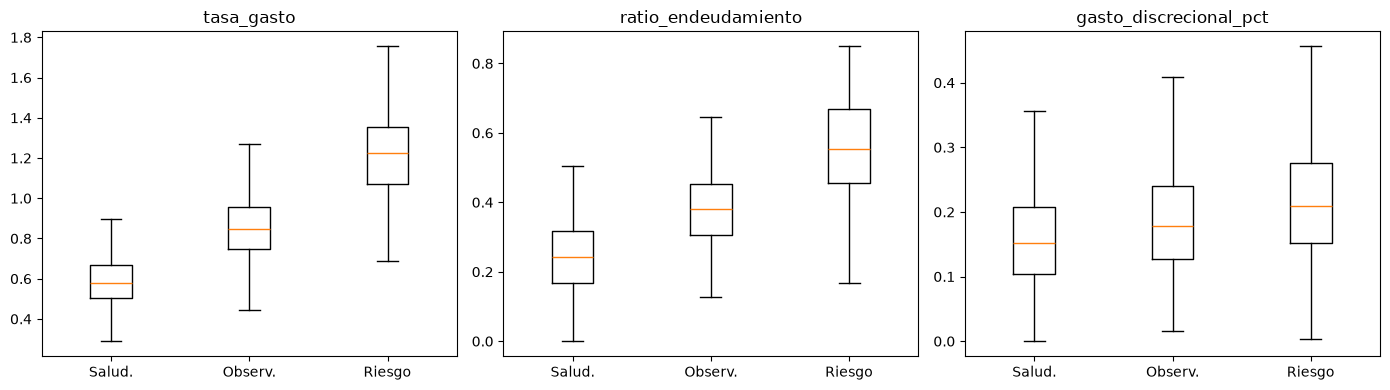

In [14]:
fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
for eje, columna in zip(ejes, ["tasa_gasto", "ratio_endeudamiento", "gasto_discrecional_pct"]):
    datos = [X_perfil.loc[y_perfil == p, columna] for p in features.PERFILES]
    eje.boxplot(datos, tick_labels=["Salud.", "Observ.", "Riesgo"], showfliers=False)
    eje.set_title(columna)
plt.tight_layout()
plt.show()

`tasa_gasto` separa bien las tres clases y `ratio_endeudamiento` la refuerza. El gasto
discrecional apenas discrimina; se conserva porque es el atributo sobre el que las
recomendaciones pueden actuar.

## 8. Preparación del conjunto de entrenamiento

Tres particiones, cada una para una pregunta distinta:

1. Aleatoria estratificada (clasificador): rendimiento con comercios ya conocidos.
2. Por comercio (clasificador): rendimiento ante un comercio nunca visto.
3. `StratifiedGroupKFold` agrupada por usuario (perfil). Los 6 meses de un usuario comparten
   ingreso, deuda y etiqueta; si el mismo usuario cae en train y en test, el modelo lo
   reconoce en lugar de aprender el patrón y la métrica sale inflada.

In [15]:
entrenables = transacciones[
    (transacciones["tipo"] == "egresos") & transacciones["categoria"].notna()
].copy()
entrenables["descripcion_limpia"] = entrenables["descripcion_limpia"].fillna("")
entrenables = entrenables[entrenables["descripcion_limpia"].str.len() > 0]

print(f"{len(entrenables):,} egresos etiquetados | {entrenables['comercio'].nunique()} comercios únicos")

X_txt_tr, X_txt_te, y_txt_tr, y_txt_te = train_test_split(
    entrenables["descripcion_limpia"], entrenables["categoria"],
    test_size=0.25, random_state=SEMILLA, stratify=entrenables["categoria"],
)
print(f"partición aleatoria -> train {len(X_txt_tr):,} | test {len(X_txt_te):,}")

58,894 egresos etiquetados | 159 comercios únicos
partición aleatoria -> train 44,170 | test 14,724


In [16]:
# Partición por comercio: el 25% de los comercios de CADA categoría se reserva entero.
rng = np.random.RandomState(7)
por_comercio = entrenables.groupby("comercio")["categoria"].first()

comercios_test = []
for _, grupo in por_comercio.groupby(por_comercio):
    nombres = sorted(grupo.index)
    k = max(1, round(len(nombres) * 0.25))
    comercios_test += list(rng.choice(nombres, size=k, replace=False))
comercios_test = set(comercios_test)

mascara_test = entrenables["comercio"].isin(comercios_test)
print(f"comercios reservados: {len(comercios_test)}/{por_comercio.size}")
print(f"filas -> train {(~mascara_test).sum():,} | test {mascara_test.sum():,}")

comercios reservados: 40/159
filas -> train 44,275 | test 14,619


## 9. Entrenamiento del modelo de clasificación de gastos

El vectorizador combina dos vistas del texto:

- Palabras (1-2 gramas) para el nombre del comercio: `supermercado exito`.
- Caracteres (`char_wb`, 3-5 gramas), que sobreviven a los errores tipográficos: `pemx` sigue
  compartiendo n-gramas con `pemex`.

`LinearSVC` va bien con texto disperso pero no da probabilidades, y la API necesita una
confianza para degradar a `otras` cuando duda. `CalibratedClassifierCV` lo envuelve y produce
probabilidades calibradas.

In [17]:
def construir_vectorizador():
    return FeatureUnion([
        ("palabra", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("caracter", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, sublinear_tf=True)),
    ])

clasificador = Pipeline([
    ("vectorizador", construir_vectorizador()),
    ("clf", CalibratedClassifierCV(LinearSVC(C=1.0, random_state=SEMILLA), cv=3)),
])

inicio = time.time()
clasificador.fit(X_txt_tr, y_txt_tr)
print(f"entrenado en {time.time() - inicio:.1f}s")
print("vocabulario:", sum(len(v.vocabulary_) for _, v in clasificador[0].transformer_list), "términos")

entrenado en 10.6s
vocabulario: 14443 términos


## 10. Evaluación del modelo

### 10.1 Partición aleatoria (comercios conocidos)

In [18]:
pred_txt = clasificador.predict(X_txt_te)
acc_aleatorio = accuracy_score(y_txt_te, pred_txt)
f1_aleatorio = f1_score(y_txt_te, pred_txt, average="macro")

print(f"accuracy  {acc_aleatorio:.4f}")
print(f"f1-macro  {f1_aleatorio:.4f}")
print()
print(classification_report(y_txt_te, pred_txt, digits=3))

accuracy  0.9999
f1-macro  0.9999

              precision    recall  f1-score   support

alimentacion      1.000     1.000     1.000      1430
   educacion      1.000     1.000     1.000      1490
        ocio      1.000     1.000     1.000      2295
       otras      0.999     1.000     1.000      1435
       salud      1.000     1.000     1.000      2008
   servicios      1.000     1.000     1.000      2308
  transporte      1.000     1.000     1.000      1487
    vivienda      1.000     1.000     1.000      2271

    accuracy                          1.000     14724
   macro avg      1.000     1.000     1.000     14724
weighted avg      1.000     1.000     1.000     14724



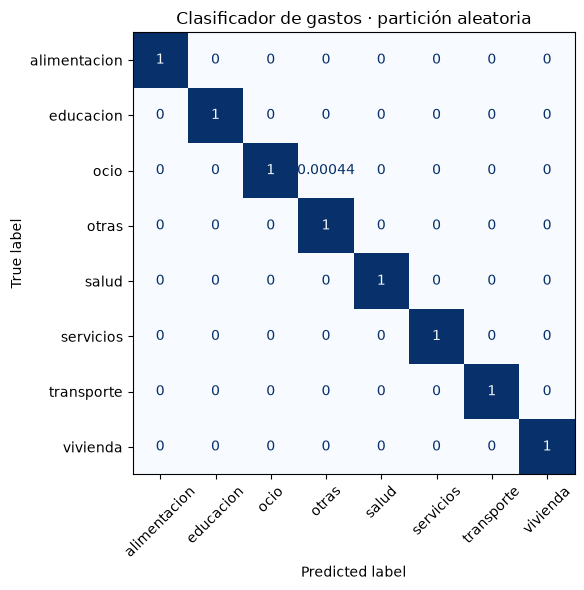

In [19]:
fig, eje = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_txt_te, pred_txt, ax=eje, cmap="Blues", colorbar=False, xticks_rotation=45, normalize="true"
)
eje.set_title("Clasificador de gastos · partición aleatoria")
plt.tight_layout()
plt.show()

Prácticamente perfecto, y conviene explicar por qué: en el dataset cada comercio pertenece a
una única categoría, así que memorizar el nombre basta. Esta métrica no predice el
rendimiento en producción. Lo que sí muestra es que la normalización y los n-gramas de
caracteres absorben el ruido tipográfico.

La pregunta interesante es la siguiente.

### 10.2 Partición por comercio (comercios nunca vistos)

In [20]:
clasificador_estres = Pipeline([
    ("vectorizador", construir_vectorizador()),
    ("clf", CalibratedClassifierCV(LinearSVC(C=1.0, random_state=SEMILLA), cv=3)),
])
clasificador_estres.fit(
    entrenables.loc[~mascara_test, "descripcion_limpia"],
    entrenables.loc[~mascara_test, "categoria"],
)

y_estres = entrenables.loc[mascara_test, "categoria"]
pred_estres = clasificador_estres.predict(entrenables.loc[mascara_test, "descripcion_limpia"])

acc_estres = accuracy_score(y_estres, pred_estres)
f1_estres = f1_score(y_estres, pred_estres, average="macro")
print(f"accuracy  {acc_estres:.4f}")
print(f"f1-macro  {f1_estres:.4f}")
print()
print(classification_report(y_estres, pred_estres, digits=3))

accuracy  0.4111
f1-macro  0.4181

              precision    recall  f1-score   support

alimentacion      0.234     0.631     0.341      1511
   educacion      0.691     0.310     0.428      1477
        ocio      0.377     0.335     0.355      1476
       otras      0.009     0.011     0.010      1394
       salud      0.727     0.995     0.840      1329
   servicios      0.574     0.450     0.505      2242
  transporte      0.492     0.496     0.494      1430
    vivienda      0.562     0.279     0.373      3760

    accuracy                          0.411     14619
   macro avg      0.458     0.438     0.418     14619
weighted avg      0.479     0.411     0.413     14619



La caída es grande y es el resultado más informativo del notebook.

Por categoría: `salud` aguanta bien porque sus comercios comparten vocabulario (*farmacia*,
*clínica*, *consulta*), mientras que `otras` y `servicios` se hunden. `otras` es un cajón de
sastre sin vocabulario propio, y `servicios` mezcla telecomunicaciones, streaming y servicios
públicos, que no comparten palabras entre sí.

De aquí salen tres decisiones:

1. Umbral de confianza: por debajo de 0.5 la API devuelve `otras` en lugar de arriesgar una
   categoría equivocada.
2. Clasificador de respaldo por palabras clave en el backend, que cubre los comercios
   frecuentes aunque el modelo no esté disponible o dude.
3. El catálogo de comercios hay que alimentarlo. La mejora real pasa por reentrenar con
   comercios nuevos, no por cambiar de algoritmo.

In [21]:
# ¿El umbral de confianza hace lo que promete? Debe reducir errores a costa de cobertura.
proba_estres = clasificador_estres.predict_proba(entrenables.loc[mascara_test, "descripcion_limpia"])
confianza = proba_estres.max(axis=1)

filas = []
for umbral in [0.0, 0.3, 0.5, 0.7, 0.9]:
    seguras = confianza >= umbral
    filas.append({
        "umbral": umbral,
        "cobertura": seguras.mean(),
        "accuracy sobre lo aceptado": accuracy_score(y_estres[seguras], pred_estres[seguras]) if seguras.any() else np.nan,
    })
pd.DataFrame(filas).round(3)

,umbral,cobertura,accuracy sobre lo aceptado
0,0.0,1.000,0.411
1,0.3,0.892,0.379
2,0.5,0.754,0.444
3,0.7,0.666,0.494
4,0.9,0.500,0.592


El umbral 0.5 que usa la API es un equilibrio razonable: descarta buena parte de las
predicciones dudosas y sube la precisión de lo que sí se afirma. Lo descartado cae en `otras`.

## 11. Modelo para perfil financiero

Se comparan tres familias con la misma validación cruzada agrupada por usuario.

In [22]:
cv_agrupada = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

candidatos = {
    "Regresión logística": Pipeline([
        ("escalador", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, C=1.0, random_state=SEMILLA)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, min_samples_leaf=5, random_state=SEMILLA),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15, random_state=SEMILLA),
}

resultados = []
for nombre, modelo in candidatos.items():
    marcas = cross_val_score(modelo, X_perfil, y_perfil, groups=grupos,
                             cv=cv_agrupada, scoring="f1_macro")
    resultados.append({"modelo": nombre, "f1_macro": marcas.mean(), "desv": marcas.std()})

tabla = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False).round(4)
tabla

,modelo,f1_macro,desv
0,Regresión logística,0.8613,0.0166
1,Random Forest,0.8395,0.0157
2,Gradient Boosting,0.8123,0.0267


Gana la regresión logística, y no por poco margen frente a los árboles. Encaja con cómo se
generaron los datos: la etiqueta viene de una combinación lineal de presión de gasto, deuda y
hábito de ahorro.

Además da probabilidades calibradas (la API devuelve `probabilidad`) y coeficientes
interpretables (la API devuelve `factores`). Con un Random Forest habría que recurrir a SHAP
para lo segundo.

In [23]:
modelo_perfil = candidatos["Regresión logística"]
pred_perfil = cross_val_predict(modelo_perfil, X_perfil, y_perfil, groups=grupos, cv=cv_agrupada)

f1_perfil = f1_score(y_perfil, pred_perfil, average="macro")
acc_perfil = accuracy_score(y_perfil, pred_perfil)
print(f"accuracy  {acc_perfil:.4f}")
print(f"f1-macro  {f1_perfil:.4f}")
print()
print(classification_report(y_perfil, pred_perfil, digits=3))

accuracy  0.8692
f1-macro  0.8613

                precision    recall  f1-score   support

En observación      0.785     0.787     0.786       732
     En riesgo      0.914     0.920     0.917      1146
     Saludable      0.889     0.874     0.881       522

      accuracy                          0.869      2400
     macro avg      0.863     0.860     0.861      2400
  weighted avg      0.869     0.869     0.869      2400



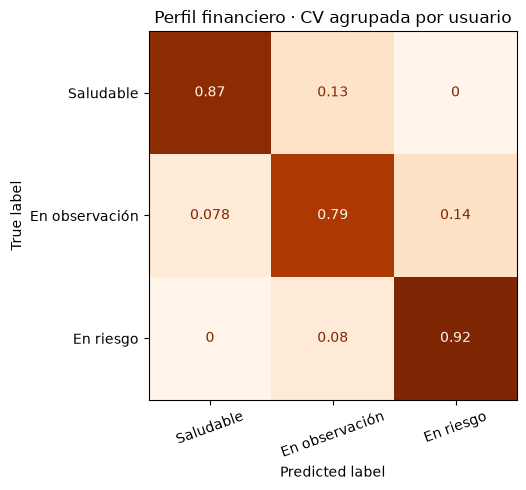

In [24]:
fig, eje = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_perfil, pred_perfil, labels=list(features.PERFILES), ax=eje,
    cmap="Oranges", colorbar=False, xticks_rotation=20, normalize="true",
)
eje.set_title("Perfil financiero · CV agrupada por usuario")
plt.tight_layout()
plt.show()

Los errores se concentran en la clase intermedia y son casi siempre a una clase adyacente:
`En observación` se confunde con sus dos vecinas, mientras que `Saludable` y `En riesgo` casi
nunca se confunden entre sí. Para el producto es el patrón menos dañino, porque el sistema no
le dice a alguien en riesgo que está sano.

Que la clase del medio sea la difícil era esperable: es una banda estrecha del score continuo
y el ruido de la simulación cae sobre sus fronteras.

In [25]:
modelo_perfil.fit(X_perfil, y_perfil)

coeficientes = pd.DataFrame(
    modelo_perfil.named_steps["clf"].coef_,
    columns=list(features.COLUMNAS_PERFIL),
    index=modelo_perfil.named_steps["clf"].classes_,
).T

print("Coeficientes de la clase 'En riesgo' (positivo = empuja hacia el riesgo):")
coeficientes["En riesgo"].sort_values(ascending=False).head(8).round(3)

Coeficientes de la clase 'En riesgo' (positivo = empuja hacia el riesgo):


ratio_endeudamiento       2.364
vivienda_sobre_ingreso    1.408
tasa_gasto                1.065
gasto_total               1.040
pct_alimentacion          0.440
pct_servicios             0.349
pct_salud                 0.326
pct_educacion             0.253
Name: En riesgo, dtype: float64

El modelo aprendió lo esperable: `tasa_gasto` y `ratio_endeudamiento` empujan al riesgo,
`capacidad_ahorro` y `ahorro_ordinal` lo contienen. Estos coeficientes son los que
`srv-python` usa para construir el campo `factores` de la respuesta.

## 12. Generación de recomendaciones

Las recomendaciones se apoyan en un patrón de referencia: la mediana del peso de cada
categoría entre los usuarios con perfil `Saludable`. Comparar al usuario contra ese patrón
permite pasar de un consejo genérico a uno concreto ("tu gasto en ocio pesa 2.3 veces lo que
pesa en un perfil saludable").

Estos umbrales se serializan junto al modelo y los consume el motor de reglas del backend.

In [26]:
mascara_sana = y_perfil == "Saludable"
referencia = {
    c: float(X_perfil.loc[mascara_sana, f"pct_{c}"].median()) for c in features.CATEGORIAS
}
referencia["tasa_gasto"] = float(X_perfil.loc[mascara_sana, "tasa_gasto"].median())

pd.Series(referencia).round(4).to_frame("mediana en perfiles saludables")

,mediana en perfiles saludables
alimentacion,0.0569
transporte,0.0617
salud,0.0808
vivienda,0.4342
educacion,0.0616
ocio,0.0914
servicios,0.0917
otras,0.0521
tasa_gasto,0.5780


In [27]:
def generar_recomendaciones(vector, perfil, referencia, maximo=4):
    # Reglas ordenadas por impacto: primero lo estructural (gastar más de lo que
    # se ingresa), después la deuda, después el hábito de ahorro y por último las
    # categorías concretas desviadas respecto al patrón saludable.
    consejos = []

    if vector["tasa_gasto"] >= 1.0:
        consejos.append("Tus gastos superan tu ingreso mensual: es la prioridad número uno. "
                        "Identifica los dos gastos variables más grandes y recórtalos este mes.")
    elif vector["tasa_gasto"] >= referencia["tasa_gasto"] * 1.25:
        consejos.append(f"Gastas el {vector['tasa_gasto']*100:.0f}% de tu ingreso, por encima del "
                        f"{referencia['tasa_gasto']*100:.0f}% típico de un perfil saludable.")

    if vector["ratio_endeudamiento"] >= 0.40:
        consejos.append("Tu nivel de endeudamiento supera el 40% del ingreso. Prioriza amortizar "
                        "la deuda de mayor interés antes de asumir nuevos compromisos.")

    if vector["ahorro_ordinal"] <= 1:
        consejos.append("Automatiza un ahorro fijo el mismo día que recibes tu ingreso, aunque sea "
                        "pequeño: la constancia importa más que el monto.")

    desviaciones = []
    for categoria in features.CATEGORIAS_DISCRECIONALES + ("transporte", "servicios"):
        actual, patron = vector[f"pct_{categoria}"], referencia[categoria]
        if patron > 0.01 and actual > patron * 1.5 and actual > 0.10:
            desviaciones.append((actual / patron, categoria, actual))
    for razon, categoria, actual in sorted(desviaciones, reverse=True)[:2]:
        consejos.append(f"Tu gasto en {categoria} representa el {actual*100:.0f}% del total, "
                        f"{razon:.1f} veces el patrón de un perfil saludable. Es la palanca más "
                        f"rápida para liberar margen.")

    if not consejos:
        consejos.append("Tus indicadores están en rango saludable. Mantén el hábito y considera "
                        "destinar el excedente a un fondo de emergencia de 3 a 6 meses de gastos.")

    if perfil == "En riesgo" and len(consejos) < maximo:
        consejos.append("Revisa tus suscripciones recurrentes: son gastos pequeños y constantes "
                        "que suelen pasar inadvertidos en el resumen mensual.")

    return consejos[:maximo]


for indice in [X_perfil.index[y_perfil == p][0] for p in features.PERFILES]:
    vector = X_perfil.loc[indice]
    perfil = y_perfil.loc[indice]
    print(f"--- {perfil} (tasa_gasto={vector['tasa_gasto']:.2f}, deuda={vector['ratio_endeudamiento']:.2f}) ---")
    for consejo in generar_recomendaciones(vector, perfil, referencia):
        print("  *", consejo)
    print()

--- Saludable (tasa_gasto=0.48, deuda=0.20) ---
  * Automatiza un ahorro fijo el mismo día que recibes tu ingreso, aunque sea pequeño: la constancia importa más que el monto.
  * Tu gasto en ocio representa el 20% del total, 2.2 veces el patrón de un perfil saludable. Es la palanca más rápida para liberar margen.

--- En observación (tasa_gasto=1.26, deuda=0.26) ---
  * Tus gastos superan tu ingreso mensual: es la prioridad número uno. Identifica los dos gastos variables más grandes y recórtalos este mes.
  * Automatiza un ahorro fijo el mismo día que recibes tu ingreso, aunque sea pequeño: la constancia importa más que el monto.
  * Tu gasto en otras representa el 14% del total, 2.7 veces el patrón de un perfil saludable. Es la palanca más rápida para liberar margen.
  * Tu gasto en transporte representa el 13% del total, 2.2 veces el patrón de un perfil saludable. Es la palanca más rápida para liberar margen.

--- En riesgo (tasa_gasto=1.50, deuda=0.33) ---
  * Tus gastos superan tu 

## 13. Serialización del modelo y publicación en OCI Object Storage

Se guardan tres artefactos:

| Artefacto | Contenido |
|---|---|
| `clasificador_gastos.joblib` | pipeline completo (vectorizador + clasificador calibrado) |
| `modelo_perfil.joblib` | pipeline completo (escalador + regresión logística) |
| `metadatos.json` | versión, métricas, orden de columnas, categorías, perfiles y patrón de referencia |

Se serializa el pipeline entero y no solo el estimador: guardar el modelo sin su vectorizador
obligaría a reconstruirlo en la API, y cualquier diferencia de parámetros rompería la
correspondencia con lo entrenado.

`metadatos.json` incluye el orden exacto de `COLUMNAS_PERFIL`. `srv-python` lo valida al
arrancar y se niega a usar el modelo si no coincide, en vez de servir predicciones sobre un
vector desalineado.

In [28]:
ruta_clasificador = ARTEFACTOS / "clasificador_gastos.joblib"
ruta_perfil = ARTEFACTOS / "modelo_perfil.joblib"
ruta_metadatos = ARTEFACTOS / "metadatos.json"

# El clasificador que se publica es el entrenado con TODOS los datos: las
# particiones anteriores existían para medir, no para producir el artefacto final.
clasificador_final = Pipeline([
    ("vectorizador", construir_vectorizador()),
    ("clf", CalibratedClassifierCV(LinearSVC(C=1.0, random_state=SEMILLA), cv=3)),
])
clasificador_final.fit(entrenables["descripcion_limpia"], entrenables["categoria"])

# El modelo de perfil se reajusta sobre un array en vez de un DataFrame. Al
# entrenar con DataFrame, scikit-learn guarda los nombres de columna y avisa
# (o falla, en versiones futuras) si en inferencia le llega un array sin ellos.
# srv-python no tiene pandas instalado a propósito, así que le pasa un array:
# serializando así, el objeto guardado coincide con cómo se va a usar. El orden
# de las columnas sigue garantizado por COLUMNAS_PERFIL.
modelo_perfil.fit(X_perfil.to_numpy(), y_perfil)

joblib.dump(clasificador_final, ruta_clasificador, compress=3)
joblib.dump(modelo_perfil, ruta_perfil, compress=3)

metadatos = {
    "version": VERSION_MODELO,
    "entrenado_en": pd.Timestamp.now().isoformat(timespec="seconds"),
    "scikit_learn": sklearn.__version__,
    "semilla": SEMILLA,
    "dataset": {
        "usuarios": int(usuarios["usuario_id"].nunique()),
        "transacciones": int(len(transacciones)),
        "egresos_etiquetados": int(len(entrenables)),
        "filas_usuario_mes": int(len(X_perfil)),
        "origen": "sintetico (scripts/generador_usuarios.py, semilla 42)",
    },
    "categorias": list(features.CATEGORIAS),
    "perfiles": list(features.PERFILES),
    "columnas_perfil": list(features.COLUMNAS_PERFIL),
    "umbral_confianza": 0.5,
    "metricas": {
        "clasificador_particion_aleatoria": {
            "accuracy": round(float(acc_aleatorio), 4),
            "f1_macro": round(float(f1_aleatorio), 4),
        },
        "clasificador_comercios_no_vistos": {
            "accuracy": round(float(acc_estres), 4),
            "f1_macro": round(float(f1_estres), 4),
        },
        "perfil_cv_agrupada": {
            "accuracy": round(float(acc_perfil), 4),
            "f1_macro": round(float(f1_perfil), 4),
        },
    },
    "referencia_saludable": {k: round(v, 4) for k, v in referencia.items()},
}

ruta_metadatos.write_text(json.dumps(metadatos, ensure_ascii=False, indent=2), encoding="utf-8")

for ruta in (ruta_clasificador, ruta_perfil, ruta_metadatos):
    print(f"{ruta.name:30s} {ruta.stat().st_size/1024:8.1f} KB")

clasificador_gastos.joblib       2825.5 KB
modelo_perfil.joblib                1.9 KB
metadatos.json                      1.6 KB


### 13.1 Publicación en OCI Object Storage

`oci_storage.py` es el mismo módulo que usa `srv-python` para descargar. Sin credenciales
configuradas la publicación se omite con un aviso y el notebook continúa; los artefactos
locales bastan para desarrollar. El detalle del bucket y las variables de entorno está en
`docs/OCI.md`.

In [29]:
if oci_storage.configurado():
    print("OCI configurado:", oci_storage.describir())
    for ruta in (ruta_clasificador, ruta_perfil, ruta_metadatos):
        ok = oci_storage.subir(str(ruta), ruta.name)
        print(f"  {ruta.name:30s} {'publicado' if ok else 'FALLÓ'} -> {oci_storage.uri(ruta.name)}")
else:
    print("OCI no configurado en este entorno: se omite la publicación.")
    print("Los artefactos quedan en", ARTEFACTOS)
    print("Destino previsto:", oci_storage.uri(ruta_clasificador.name))

OCI no configurado en este entorno: se omite la publicación.
Los artefactos quedan en C:\Users\Rayle\Desktop\G9-LATAM-TEAM-44-FinanceAI-main\ciencia-datos\artefactos
Destino previsto: oci://finance-ai-models/clasificador_gastos.joblib


## 14. Pruebas del modelo

Se recargan los artefactos desde disco, como haría el servicio al arrancar, y se ejecutan los
tres ejemplos de uso documentados de la API. Lo que importa aquí no es la puntuación en el
test, sino que el objeto serializado produzca el mismo resultado tras salir y volver a entrar
del disco.

In [30]:
clasificador_cargado = joblib.load(ruta_clasificador)
perfil_cargado = joblib.load(ruta_perfil)
metadatos_cargados = json.loads(ruta_metadatos.read_text(encoding="utf-8"))

assert metadatos_cargados["columnas_perfil"] == list(features.COLUMNAS_PERFIL)
print("artefactos recargados y contrato de columnas verificado")

muestra = entrenables["descripcion_limpia"].head(500)
assert (clasificador_cargado.predict(muestra) == clasificador_final.predict(muestra)).all()
print("el clasificador recargado reproduce exactamente las predicciones originales")

artefactos recargados y contrato de columnas verificado
el clasificador recargado reproduce exactamente las predicciones originales


In [31]:
CASOS = [
    ("Perfil saludable", {
        "ingreso_mensual": 4500, "nivel_endeudamiento": 12, "frecuencia_ahorro": "Alta",
        "transacciones": [
            {"descripcion": "Supermercado Exito", "valor": 420},
            {"descripcion": "Gasolinera Terpel", "valor": 180},
            {"descripcion": "Netflix Streaming", "valor": 40},
            {"descripcion": "Arriendo Apartamento", "valor": 900},
        ]}),
    ("Perfil en observación", {
        "ingreso_mensual": 3000, "nivel_endeudamiento": 35, "frecuencia_ahorro": "Media",
        "transacciones": [
            {"descripcion": "TRF/POS Supermercado Jumbo REF993021", "valor": 620},
            {"descripcion": "Uber Trip BOGOTA", "valor": 240},
            {"descripcion": "Cinepolis Entradas", "valor": 180},
            {"descripcion": "Arriendo Apartamento", "valor": 1100},
            {"descripcion": "Farmacia San Pablo", "valor": 130},
        ]}),
    ("Perfil en riesgo", {
        "ingreso_mensual": 2200, "nivel_endeudamiento": 65, "frecuencia_ahorro": "Nula",
        "transacciones": [
            {"descripcion": "### supermercado ara", "valor": 700},
            {"descripcion": "Bar El Callejon", "valor": 380},
            {"descripcion": "Steam Games", "valor": 210},
            {"descripcion": "Cuota Hipoteca Vivienda", "valor": 1200},
            {"descripcion": "Gasolinera Pemx", "valor": 260},
        ]}),
]

for titulo, caso in CASOS:
    descripciones = [features.normalizar_texto(t["descripcion"]) for t in caso["transacciones"]]
    probabilidades = clasificador_cargado.predict_proba(descripciones)
    clases = clasificador_cargado.classes_

    resumen = {c: 0.0 for c in features.CATEGORIAS}
    detalle = []
    for transaccion, fila in zip(caso["transacciones"], probabilidades):
        indice = int(fila.argmax())
        confianza = float(fila[indice])
        # Mismo umbral que aplica la API: por debajo de 0.5, "otras".
        categoria = clases[indice] if confianza >= 0.5 else "otras"
        resumen[categoria] += transaccion["valor"]
        detalle.append((transaccion["descripcion"], categoria, confianza))

    vector = features.construir_features_perfil(
        caso["ingreso_mensual"], caso["nivel_endeudamiento"],
        caso["frecuencia_ahorro"], resumen)
    # Array, no DataFrame: exactamente la misma forma que le pasa srv-python.
    fila_x = np.array([[vector[c] for c in features.COLUMNAS_PERFIL]], dtype=float)

    etiqueta = perfil_cargado.predict(fila_x)[0]
    probabilidad = float(perfil_cargado.predict_proba(fila_x).max())

    print(f"=== {titulo} ===")
    for descripcion, categoria, confianza in detalle:
        print(f"   {descripcion[:42]:44s} -> {categoria:13s} ({confianza:.2f})")
    print(f"   perfil: {etiqueta}  (probabilidad {probabilidad:.2f})")
    for consejo in generar_recomendaciones(pd.Series(vector), etiqueta, referencia):
        print(f"     - {consejo}")
    print()

=== Perfil saludable ===
   Supermercado Exito                           -> alimentacion  (1.00)
   Gasolinera Terpel                            -> transporte    (1.00)
   Netflix Streaming                            -> ocio          (1.00)
   Arriendo Apartamento                         -> vivienda      (1.00)
   perfil: Saludable  (probabilidad 1.00)
     - Tu gasto en transporte representa el 12% del total, 1.9 veces el patrón de un perfil saludable. Es la palanca más rápida para liberar margen.

=== Perfil en observación ===
   TRF/POS Supermercado Jumbo REF993021         -> alimentacion  (1.00)
   Uber Trip BOGOTA                             -> transporte    (1.00)
   Cinepolis Entradas                           -> ocio          (1.00)
   Arriendo Apartamento                         -> vivienda      (1.00)
   Farmacia San Pablo                           -> salud         (1.00)
   perfil: En observación  (probabilidad 0.67)
     - Gastas el 76% de tu ingreso, por encima del 58% típ

Los tres casos caen donde deben, incluso con las descripciones sucias (`### supermercado
ara`, `Gasolinera Pemx`). Los mismos casos están en `docs/EJEMPLOS.md` y en la colección de
Postman, así que el comportamiento del notebook y el de la API se pueden contrastar.

## 15. Conclusiones

**Resultado**

1. Un dataset sintético reproducible (400 usuarios × 6 meses, ~64.700 transacciones) con
   doble etiquetado: categoría por transacción y perfil por usuario.
2. Un clasificador de gastos TF-IDF (palabras + caracteres) con `LinearSVC` calibrado.
3. Un modelo de perfil financiero por regresión logística, validado con partición agrupada
   por usuario.
4. Un motor de recomendaciones anclado a un patrón de referencia extraído de los datos.
5. Artefactos serializados y publicables en OCI Object Storage, con metadatos que la API
   valida al arrancar.

**Notas del proceso**

- El dato más útil no fue una métrica alta sino una baja: la caída del clasificador ante
  comercios no vistos es lo que justifica el umbral de confianza y el clasificador de
  respaldo. Sin esa segunda evaluación el 99,9% habría sido engañoso.
- Agrupar por usuario en la validación cruzada cambia el resultado. Sin agrupar, los seis
  meses de una misma persona se reparten entre train y test y la métrica premia reconocer al
  usuario.
- Dos fallos de datos que las métricas no habrían delatado: el parseo de fechas con
  `dayfirst`, que inventaba meses, y los nulos de pandas que entraban al vectorizador como el
  token `na`. Los dos aparecieron mirando los datos, no los resultados.

**Limitaciones**

- Los datos son simulados. Las métricas miden el aprendizaje de una estructura conocida, no
  el desempeño frente a extractos bancarios reales.
- El modelo de perfil hereda los pesos de la regla de simulación. Con datos reales habría que
  recalibrarlo contra una definición de salud financiera validada por alguien del dominio.
- No hay componente temporal: cada mes se evalúa por separado. Detectar tendencias, como un
  usuario que empeora mes a mes, es el siguiente paso.

**Siguientes pasos**

Incorporar transacciones reales anonimizadas, añadir atributos de evolución temporal y
monitorizar la deriva del modelo comparando la distribución de confianzas en producción
contra la del entrenamiento.